# Exploring `table.tsv`

This notebook loads a TSV abundance table (taxa as rows, samples as columns), performs some simple exploration and produces a few basic plots.

## 1. Load the table

We read the TSV file into a pandas `DataFrame`, using the first column (`#Taxon`) as row index, and display a small preview of the data. We also import the libraries used throughout the notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("table.tsv", sep="\t", index_col=0)
df.index.name = "Taxon"
print(f"Table shape: {df.shape[0]} taxa x {df.shape[1]} samples")
df.iloc[:5, :5]

Table shape: 102 taxa x 29 samples


,ERR17070056,ERR17070057,ERR17070058,ERR17070059,ERR17070060
Taxon,,,,,
u__unclassified,1503,1683,1107,1440,1702
"k__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Lactobacillaceae,g__Lactobacillus",170195,252818,172036,163889,254344
"k__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Lactobacillaceae,g__Pediococcus",1318,1964,1444,1249,1905
"k__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Leuconostocaceae,g__Leuconostoc",1500,43,22,34,36
"k__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Leuconostocaceae,g__Weissella",46,52,32,41,42


**🧑‍💻 Syntax:** `pd.read_csv(..., sep="\t", index_col=0)` parses a tab-separated file and turns the first column into the DataFrame index (row labels). `df.shape` returns `(rows, columns)`, and `.iloc[:5, :5]` slices by *position* to show the first 5 rows and 5 columns.

**🔍 The output:** the table contains **102 taxa (rows) x 29 samples (columns)**; values are raw abundance counts. Row labels are full taxonomic lineages (e.g. `k__Bacteria,p__Firmicutes,...,g__Lactobacillus`), except the first row `u__unclassified`.

## 2. Basic exploration

We compute a statistical summary of the count distribution of each sample, to get a feel for how sparse the data is.

In [11]:
# Summary statistics of the counts
df.describe().iloc[:, :6]

,ERR17070056,ERR17070057,ERR17070058,ERR17070059,ERR17070060,ERR17070061
count,102.000000,102.000000,102.000000,102.000000,102.000000,102.000000
mean,2253.470588,2619.754902,1756.980392,1968.656863,2701.392157,2516.617647
std,16967.838823,25027.316881,17029.416259,16242.854333,25201.406628,23899.300186
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.500000,2.000000,1.000000,4.500000,1.000000,2.000000
75%,52.750000,23.000000,12.000000,49.250000,17.750000,24.500000
max,170195.000000,252818.000000,172036.000000,163889.000000,254344.000000,241408.000000


**🧑‍💻 Syntax:** `df.describe()` computes count, mean, std and quartiles for each column (i.e. per sample); `.iloc[:, :6]` limits the display to the first six samples for readability.

**🔍 The output:** the median (50%) is near zero while the mean is in the thousands, and the maximum reaches hundreds of thousands. This is the typical signature of sparse, compositional profiling data: a handful of very abundant taxa dominate each sample while most taxa are rare or absent.

We compute the *library size* of each sample, i.e. the total number of counts summed over all taxa.

In [3]:
# Total counts per sample
sample_totals = df.sum(axis=0)
print("Total counts per sample (first 10):")
print(sample_totals.head(10))
print(f"\nMin: {sample_totals.min():,.0f}  Max: {sample_totals.max():,.0f}  Median: {sample_totals.median():,.0f}")

Total counts per sample (first 10):
ERR17070056    229854
ERR17070057    267215
ERR17070058    179212
ERR17070059    200803
ERR17070060    275542
ERR17070061    256695
ERR17070062    229009
ERR17070063    256823
ERR17070064    142180
ERR17070065    279290
dtype: int64

Min: 2,744  Max: 357,794  Median: 267,215


**🧑‍💻 Syntax:** `df.sum(axis=0)` sums along rows (across taxa), producing one total per sample; `axis=0` means "collapse rows". The `:,.0f` format specifier in the f-string prints numbers without decimals and with thousands separators.

**🔍 The output:** library sizes vary by more than two orders of magnitude (min ~2.7k vs max ~358k counts). Samples were therefore sequenced at very different depths, which is why comparisons later in the notebook are based on *relative* abundances.

Row names are full lineage strings. Here we parse them into a separate table with one column per taxonomic rank (phylum, class, genus), so we can later aggregate counts at a given rank.

In [4]:
# Extract taxonomic levels from the lineage strings
def get_level(taxon, prefix):
    for part in str(taxon).split(","):
        if part.startswith(prefix):
            return part.split("__", 1)[1]
    return None

tax = pd.DataFrame({
    "phylum": [get_level(t, "p__") for t in df.index],
    "class": [get_level(t, "c__") for t in df.index],
    "genus": [get_level(t, "g__") for t in df.index],
}, index=df.index)
tax.head()

,phylum,class,genus
Taxon,,,
u__unclassified,NaN,NaN,NaN
"k__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Lactobacillaceae,g__Lactobacillus",Firmicutes,Bacilli,Lactobacillus
"k__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Lactobacillaceae,g__Pediococcus",Firmicutes,Bacilli,Pediococcus
"k__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Leuconostocaceae,g__Leuconostoc",Firmicutes,Bacilli,Leuconostoc
"k__Bacteria,p__Firmicutes,c__Bacilli,o__Lactobacillales,f__Leuconostocaceae,g__Weissella",Firmicutes,Bacilli,Weissella


**🧑‍💻 Syntax:** `get_level()` splits a lineage on commas and returns the name following a rank prefix (`p__`, `c__`, `g__`, ...), or `None` when the rank is absent (shown as `NaN`). The `tax` DataFrame is built with `index=df.index`, so it is row-aligned with `df` and the two can be combined easily.

**🔍 The output:** each taxon now has readable labels, e.g. *Lactobacillus* belongs to phylum *Firmicutes*, class *Bacilli*. The `u__unclassified` row has no ranks at all, hence the `NaN`s.

We collapse the table to higher taxonomic ranks: sum the counts of all taxa that share the same phylum or genus.

In [5]:
# Aggregate counts by phylum and by genus
by_phylum = df.groupby(tax["phylum"].fillna("unclassified")).sum()
by_genus = df.groupby(tax["genus"].fillna("unclassified")).sum()

print("Total abundance by phylum:")
print(by_phylum.sum(axis=1).sort_values(ascending=False))
print("\nTop 10 genera by total abundance:")
by_genus.sum(axis=1).sort_values(ascending=False).head(10)

Total abundance by phylum:
phylum
Firmicutes          5900601
Proteobacteria       607522
unclassified          45636
Actinobacteriota      34424
Bacteroidota          23851
Patescibacteria         448
dtype: int64

Top 10 genera by total abundance:


genus
Lactobacillus      3306159
Lactococcus         836381
Staphylococcus      469170
Weissella           378415
Leuconostoc         322343
Exiguobacterium     165224
Enterobacter        146900
Enterococcus        131185
Streptococcus       116391
Pseudomonas         107293
dtype: int64

**🧑‍💻 Syntax:** `df.groupby(labels).sum()` groups rows by the given labels and sums their counts per sample. `fillna("unclassified")` gives a name to rows lacking rank information. `sum(axis=1)` then totals each group across all samples, and `sort_values(ascending=False)` ranks them.

**🔍 The output:** the community is dominated by **Firmicutes** (~5.9M counts, roughly 89% of all reads), followed by *Proteobacteria*. At genus level, *Lactobacillus* alone accounts for more than half of all counts, ahead of *Lactococcus* and *Staphylococcus*.

## 3. Simple plots

We visualize the library size of every sample as a bar chart. Since totals span two orders of magnitude, the y-axis uses a logarithmic scale.

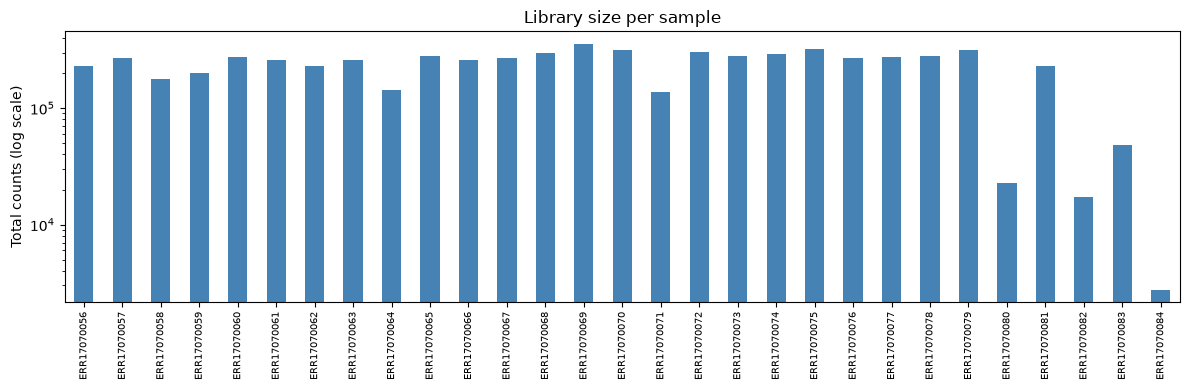

In [6]:
# Total counts per sample (log scale)
fig, ax = plt.subplots(figsize=(12, 4))
sample_totals.plot(kind="bar", ax=ax, color="steelblue")
ax.set_yscale("log")
ax.set_ylabel("Total counts (log scale)")
ax.set_title("Library size per sample")
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

**🧑‍💻 Syntax:** `plt.subplots(figsize=...)` creates a figure and an axes; `sample_totals.plot(kind="bar", ax=ax)` lets pandas draw directly onto that axes. `ax.set_yscale("log")` switches to log scale, and `plt.tight_layout()` adjusts margins so rotated sample labels are not cut off.

**🔍 The output:** most samples cluster around 10^5-10^6 counts, while a few (e.g. ERR17070084) are orders of magnitude shallower. On a linear scale those small samples would be invisible.

We identify the 10 most abundant genera overall and display them as a horizontal bar chart.

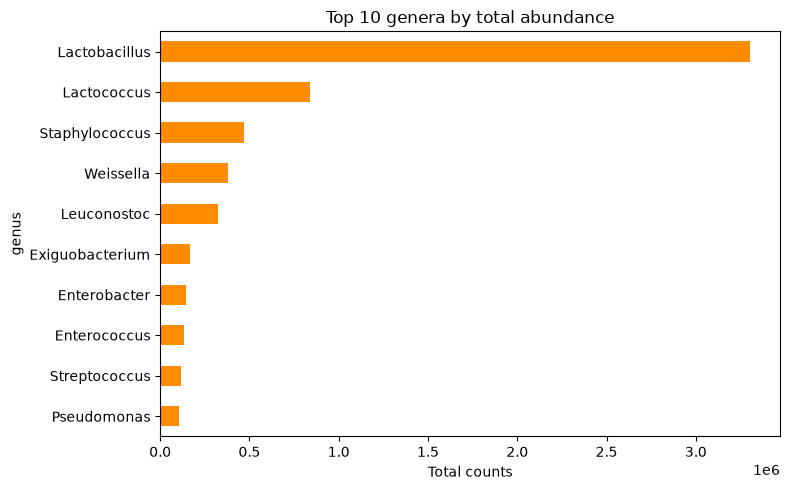

In [7]:
# Top 10 genera by total abundance
top_genera = by_genus.sum(axis=1).sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(8, 5))
top_genera.plot(kind="barh", ax=ax, color="darkorange")
ax.invert_yaxis()
ax.set_xlabel("Total counts")
ax.set_title("Top 10 genera by total abundance")
plt.tight_layout()
plt.show()

**🧑‍💻 Syntax:** the chain `sum(axis=1).sort_values(ascending=False).head(10)` totals each genus across samples, ranks them, and keeps the top 10. `kind="barh"` draws horizontal bars (easier to read long genus names), and `ax.invert_yaxis()` puts the most abundant genus on top.

**🔍 The output:** *Lactobacillus* dwarfs everything else (~3.3M counts), followed by *Lactococcus* (~0.84M) and *Staphylococcus* (~0.47M) - a composition typical of fermented-food / dairy-type microbiomes.

We convert genus-level counts to relative abundances (%) and plot each sample's composition as a stacked bar, for the top 8 genera.

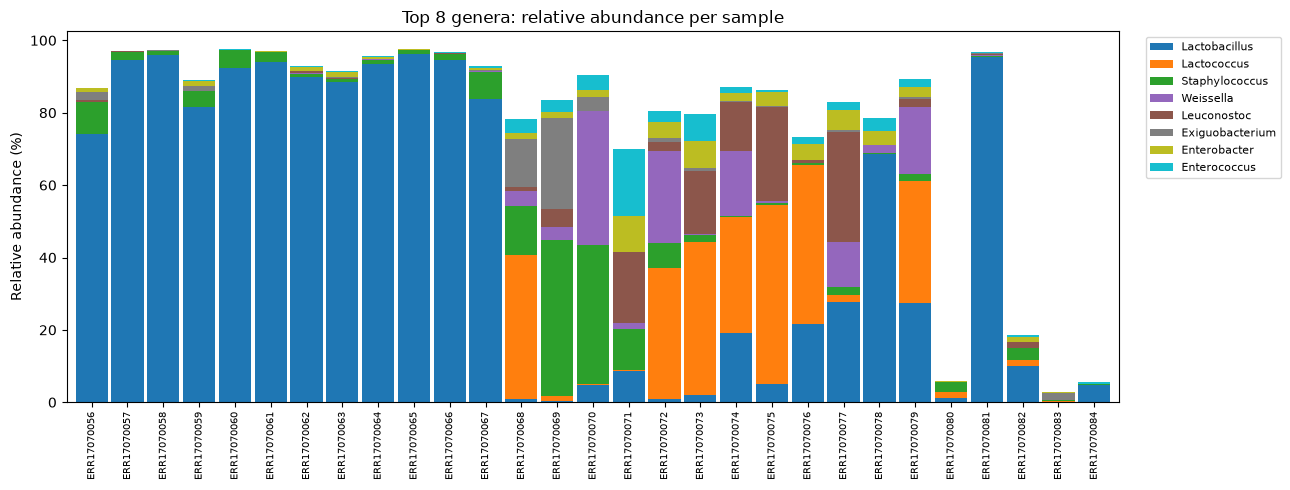

In [8]:
# Relative abundance of the top 8 genera across samples (stacked bars)
top8 = top_genera.index[:8]
rel = by_genus.loc[top8] / by_genus.sum(axis=0) * 100
fig, ax = plt.subplots(figsize=(13, 5))
rel.T.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", width=0.9)
ax.set_ylabel("Relative abundance (%)")
ax.set_title("Top 8 genera: relative abundance per sample")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

**🧑‍💻 Syntax:** dividing by `by_genus.sum(axis=0)` (per-sample totals) normalizes each sample to 100%, removing differences in sequencing depth. `rel.T` transposes the table so samples are on the x-axis and genera become the stacked segments; `stacked=True` and `colormap="tab10"` control the bar style and colors.

**🔍 The output:** this is where samples really differ. Some are almost pure *Lactobacillus*, others are dominated by *Lactococcus* or by *Leuconostoc*/*Weissella* - suggesting distinct fermentation profiles or processing batches.

Finally, we show the phylum-level composition of every sample as a heatmap, applying a `log1p` transform so rare phyla remain visible.

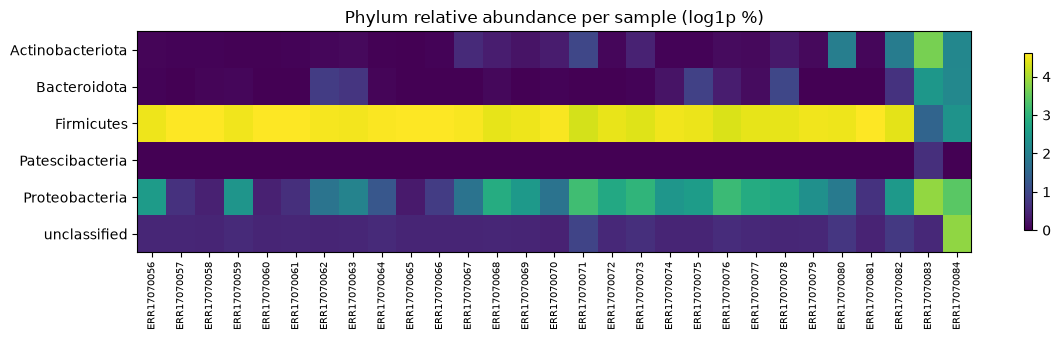

In [9]:
# Heatmap of phylum-level relative abundance (log1p transformed)
rel_phylum = by_phylum / by_phylum.sum(axis=0) * 100
fig, ax = plt.subplots(figsize=(12, 3.5))
im = ax.imshow(np.log1p(rel_phylum.values), aspect="auto", cmap="viridis")
ax.set_yticks(range(len(rel_phylum.index)), rel_phylum.index)
ax.set_xticks(range(len(rel_phylum.columns)), rel_phylum.columns, rotation=90, fontsize=7)
ax.set_title("Phylum relative abundance per sample (log1p %)")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

**🧑‍💻 Syntax:** `ax.imshow(matrix, aspect="auto", cmap="viridis")` renders a numeric matrix as colored cells (rows = phyla, columns = samples). `np.log1p(x)` computes log(1+x), which damps the overwhelming Firmicutes values; `fig.colorbar(...)` adds the color legend.

**🔍 The output:** the Firmicutes row is bright (dominant) in essentially all samples, while Proteobacteria, Actinobacteriota and Bacteroidota appear as thin, darker bands whose intensity varies sample by sample.